<a href="https://colab.research.google.com/github/Tana497/mashin/blob/main/%D0%9B%D0%A02_2_%D0%9D%D0%BE%D0%B2%D0%BE%D1%81%D0%B0%D0%B4_%D1%84%D1%96%D1%824_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import requests
from io import StringIO

In [6]:
url = "https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8#%D0%9D%D0%B0%D1%80%D0%BE%D0%B4%D0%B6%D1%83%D0%B2%D0%B0%D0%BD%D1%96%D1%81%D1%82%D1%8C"

headers = {
"User-Agent": "Mozilla/5.0",
"Accept-Language": "uk-UA,uk;q=0.9,en;q=0.8",
}

html = requests.get(url, headers=headers, timeout=30).text

df = pd.read_html(
StringIO(html),
match="Коефіцієнт народжуваності в регіонах України",
thousands=".", decimal=","
)[0]

df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,—,—
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,—
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


In [8]:
df = df.replace(['—', '-'], np.nan)

# Перетворюємо всі стовпчики з роками на числові типи (float)
years = df.columns[1:]
for col in years:
    df[col] = pd.to_numeric(df[col], errors='coerce')



In [10]:
# 3. Аналіз даних (Коротке резюме)
print("=== ІНФОРМАЦІЯ ПРО ДАТАФРЕЙМ ===")
print(df.info())

=== ІНФОРМАЦІЯ ПРО ДАТАФРЕЙМ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Регіон  28 non-null     object 
 1   1950    26 non-null     float64
 2   1960    27 non-null     float64
 3   1970    27 non-null     float64
 4   1990    28 non-null     float64
 5   2000    28 non-null     float64
 6   2012    28 non-null     float64
 7   2014    26 non-null     float64
 8   2019    24 non-null     float64
dtypes: float64(8), object(1)
memory usage: 2.1+ KB
None


In [11]:
print("\n=== ОСНОВНІ СТАТИСТИЧНІ ПОКАЗНИКИ ===")
print(df.describe())


=== ОСНОВНІ СТАТИСТИЧНІ ПОКАЗНИКИ ===
            1950       1960       1970       1990       2000       2012  \
count  26.000000  27.000000  27.000000  28.000000  28.000000  28.000000   
mean   23.092308  20.748148  15.585185  13.042857   8.207143  11.646429   
std     2.822045   2.936032   1.870357   1.527872   1.556808   1.636274   
min    18.600000  16.300000  12.700000  10.800000   6.100000   9.400000   
25%    21.150000  18.650000  14.400000  12.225000   7.075000  10.450000   
50%    22.600000  20.400000  15.200000  12.600000   7.850000  11.450000   
75%    24.600000  22.050000  16.300000  14.050000   8.950000  12.250000   
max    31.400000  27.300000  20.700000  16.800000  11.800000  15.900000   

            2014       2019  
count  26.000000  24.000000  
mean   11.142308   8.020833  
std     2.011601   1.450331  
min     5.100000   6.000000  
25%    10.225000   6.800000  
50%    11.150000   7.900000  
75%    12.100000   8.800000  
max    14.800000  11.000000  


In [12]:
print("\n=== ТОП-5 РЕГІОНІВ З НАЙВИЩОЮ НАРОДЖУВАНІСТЮ У 2019 РОЦІ ===")
print(df[['Регіон', '2019']].sort_values(by='2019', ascending=False).head(5))


=== ТОП-5 РЕГІОНІВ З НАЙВИЩОЮ НАРОДЖУВАНІСТЮ У 2019 РОЦІ ===
          Регіон  2019
25          Київ  11.0
16    Рівненська  10.7
6   Закарпатська  10.4
2      Волинська  10.1
23   Чернівецька   9.2


In [13]:
df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,NaN,NaN
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,NaN
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

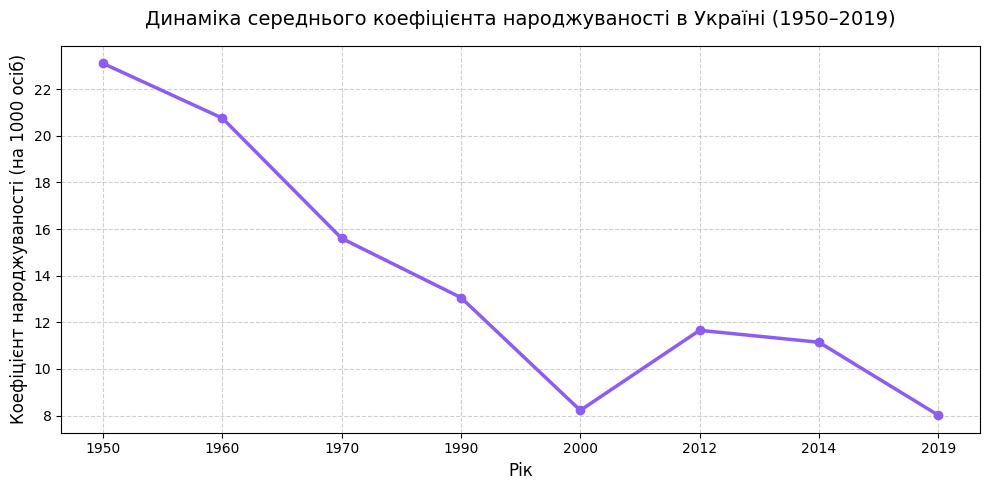

In [15]:
df_regions = df[df['Регіон'] != 'Україна']
mean_birth_rate = df_regions[years].mean()

plt.figure(figsize=(10, 5))
plt.plot(mean_birth_rate.index, mean_birth_rate.values, marker='o', color='#8b5cf6', linewidth=2.5)

plt.title('Динаміка середнього коефіцієнта народжуваності в Україні (1950–2019)', fontsize=14, pad=15)
plt.xlabel('Рік', fontsize=12)
plt.ylabel('Коефіцієнт народжуваності (на 1000 осіб)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_460/3486856519.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_2019, x='Регіон', y='2019', palette='plasma')


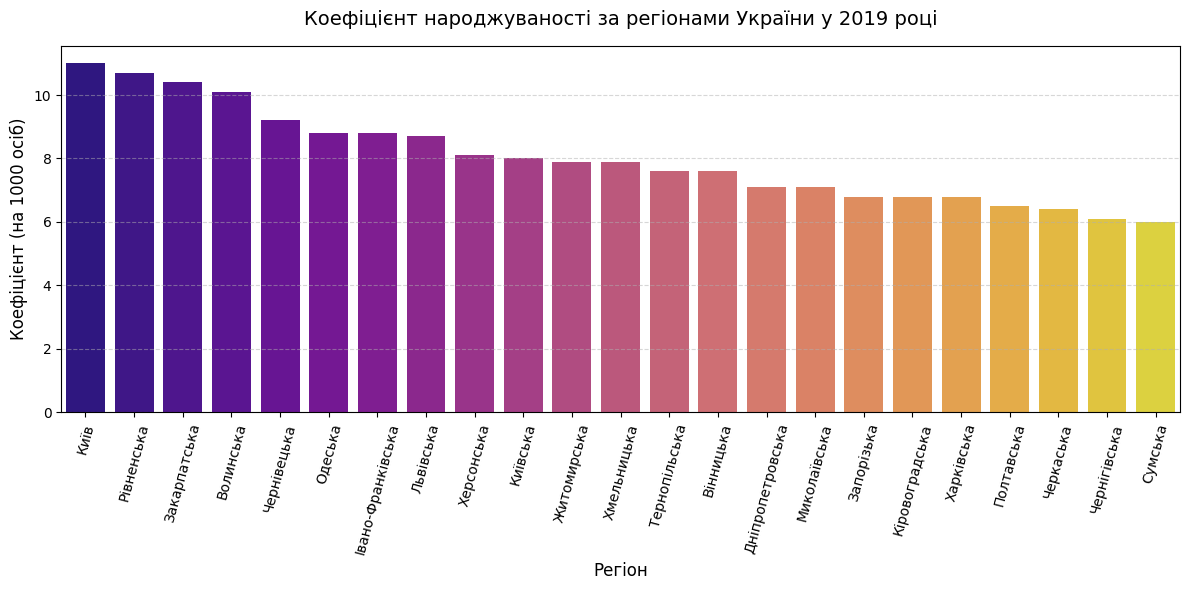

In [16]:
df_2019 = df[df['Регіон'] != 'Україна'][['Регіон', '2019']].dropna()
df_2019 = df_2019.sort_values(by='2019', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_2019, x='Регіон', y='2019', palette='plasma')

plt.title('Коефіцієнт народжуваності за регіонами України у 2019 році', fontsize=14, pad=15)
plt.xlabel('Регіон', fontsize=12)
plt.ylabel('Коефіцієнт (на 1000 осіб)', fontsize=12)
plt.xticks(rotation=75)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

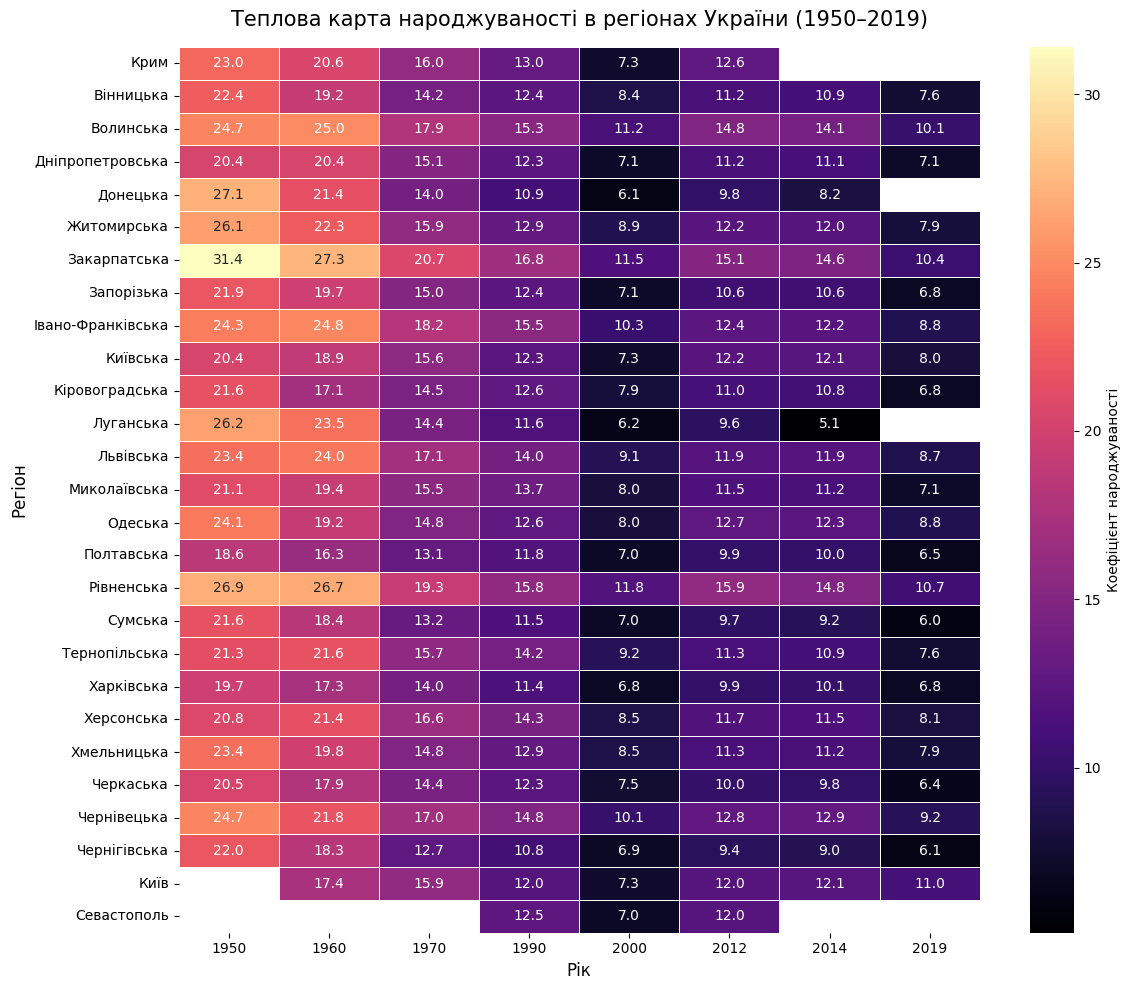

In [17]:
df_heatmap = df[df['Регіон'] != 'Україна'].set_index('Регіон')

plt.figure(figsize=(12, 10))
sns.heatmap(
    df_heatmap[years],
    cmap='magma',
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Коефіцієнт народжуваності'}
)

plt.title('Теплова карта народжуваності в регіонах України (1950–2019)', fontsize=15, pad=15)
plt.xlabel('Рік', fontsize=12)
plt.ylabel('Регіон', fontsize=12)

plt.tight_layout()
plt.show()